In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

continuous_df = pd.read_csv('continuous dataset.csv')

continuous_df.head()

,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
0,2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,0.016562,0.096100,5.364148,0,0,0
1,2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,0.016509,0.087646,5.572471,0,0,0
2,2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,0.016479,0.078735,5.871184,0,0,0
3,2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,0.016487,0.068390,5.883621,0,0,0
4,2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,0.016456,0.064362,5.611724,0,0,0


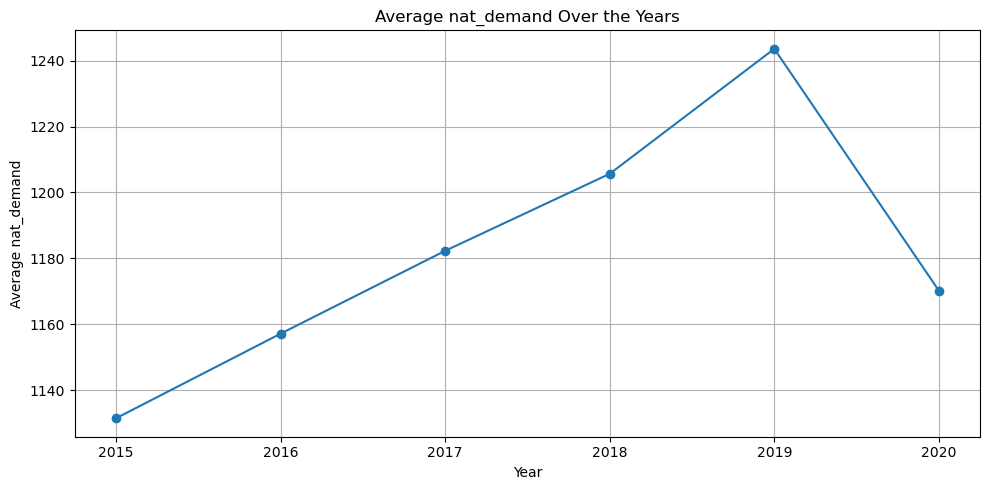

In [2]:
continuous_df['datetime'] = pd.to_datetime(continuous_df['datetime'])

continuous_df['year'] = continuous_df['datetime'].dt.year
yearly_avg = continuous_df.groupby('year')['nat_demand'].mean()

plt.figure(figsize=(10, 5))
plt.plot(yearly_avg.index, yearly_avg.values, marker='o')
plt.title('Average nat_demand Over the Years')
plt.xlabel('Year')
plt.ylabel('Average nat_demand')
plt.grid(True)
plt.tight_layout()
plt.savefig('nat_demand_over_years.png')

In [3]:
# Get average weather features
continuous_df['avg_T2M'] = continuous_df[['T2M_toc', 'T2M_san', 'T2M_dav']].mean(axis=1)
continuous_df['avg_QV2M'] = continuous_df[['QV2M_toc', 'QV2M_san', 'QV2M_dav']].mean(axis=1)
continuous_df['avg_TQL']  = continuous_df[['TQL_toc', 'TQL_san', 'TQL_dav']].mean(axis=1)
continuous_df['avg_W2M']  = continuous_df[['W2M_toc', 'W2M_san', 'W2M_dav']].mean(axis=1)

# Extract extra features
continuous_df['month']        = continuous_df['datetime'].dt.month
continuous_df['day_of_week']  = continuous_df['datetime'].dt.dayofweek 
continuous_df['hour_of_day']  = continuous_df['datetime'].dt.hour

# Define function for 4-season mapping
def get_season(month):
    if month in [12, 1, 2]:
        return 0  # Winter
    elif month in [3, 4, 5]:
        return 1  # Spring
    elif month in [6, 7, 8]:
        return 2  # Summer
    else:
        return 3  # Fall

# Add season column
continuous_df['season'] = continuous_df['month'].apply(get_season)

#Add weekend column
continuous_df['is_weekend'] = continuous_df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# Add 1-hour lag, 24-hour lag, and 1-week lag of `nat_demand`.

continuous_df['nat_demand_1hr_lag']    = continuous_df['nat_demand'].shift(1)
continuous_df['nat_demand_24hr_lag']   = continuous_df['nat_demand'].shift(24)
continuous_df['nat_demand_1week_lag']  = continuous_df['nat_demand'].shift(168)  # 24*7=168

continuous_df

,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,...,avg_TQL,avg_W2M,month,day_of_week,hour_of_day,season,is_weekend,nat_demand_1hr_lag,nat_demand_24hr_lag,nat_demand_1week_lag
0,2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,...,0.038043,12.514547,1,5,1,0,1,NaN,NaN,NaN
1,2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,...,0.035131,12.806978,1,5,2,0,1,970.3450,NaN,NaN
2,2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,...,0.031881,13.067006,1,5,3,0,1,912.1755,NaN,NaN
3,2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,...,0.029087,12.837574,1,5,4,0,1,900.2688,NaN,NaN
4,2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,...,0.027790,12.177134,1,5,5,0,1,889.9538,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48043,2020-06-26 20:00:00,1128.5592,27.246545,0.020303,0.055511,9.289304,25.715295,0.019746,0.121552,1.990773,...,0.109314,4.574912,6,4,20,2,0,1127.2491,1279.2819,1207.3977
48044,2020-06-26 21:00:00,1112.7488,27.099573,0.020395,0.053848,9.837504,25.552698,0.019632,0.153870,2.094459,...,0.121343,4.815926,6,4,21,2,0,1128.5592,1260.8193,1175.9687
48045,2020-06-26 22:00:00,1081.5680,26.971155,0.020448,0.057251,10.262464,25.393030,0.019518,0.144531,2.396369,...,0.118347,5.153183,6,4,22,2,0,1112.7488,1226.9634,1123.2326
48046,2020-06-26 23:00:00,1041.6240,26.867487,0.020464,0.064178,10.326567,25.258112,0.019403,0.108063,2.720871,...,0.108337,5.395190,6,4,23,2,0,1081.5680,1184.3443,1080.3560


In [4]:
# Final column ordering based on your updated instructions
final_columns = [
    'nat_demand','holiday','school','avg_T2M','avg_QV2M','avg_TQL','avg_W2M','season','month',
    'day_of_week','hour_of_day','is_weekend','year','nat_demand_1hr_lag','nat_demand_24hr_lag',
    'nat_demand_1week_lag',
]

# Prepare final dataframe
final_df = continuous_df[final_columns]

final_df = final_df.dropna().reset_index(drop=True)

final_df

,nat_demand,holiday,school,avg_T2M,avg_QV2M,avg_TQL,avg_W2M,season,month,day_of_week,hour_of_day,is_weekend,year,nat_demand_1hr_lag,nat_demand_24hr_lag,nat_demand_1week_lag
0,906.9580,0,0,23.606704,0.016457,0.066152,13.350307,0,1,5,1,1,2015,949.5031,943.6081,970.3450
1,863.5135,0,0,23.544295,0.016462,0.063599,13.840689,0,1,5,2,1,2015,906.9580,917.0640,912.1755
2,848.4447,0,0,23.504724,0.016503,0.065865,14.086840,0,1,5,3,1,2015,863.5135,895.9092,900.2688
3,839.8821,0,0,23.527714,0.016571,0.062487,14.010866,0,1,5,4,1,2015,848.4447,885.2720,889.9538
4,847.1073,0,0,23.570540,0.016650,0.054685,13.581109,0,1,5,5,1,2015,839.8821,884.8111,893.6865
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47875,1128.5592,0,1,25.569462,0.019477,0.109314,4.574912,2,6,4,20,0,2020,1127.2491,1279.2819,1207.3977
47876,1112.7488,0,1,25.448531,0.019449,0.121343,4.815926,2,6,4,21,0,2020,1128.5592,1260.8193,1175.9687
47877,1081.5680,0,1,25.340946,0.019431,0.118347,5.153183,2,6,4,22,0,2020,1112.7488,1226.9634,1123.2326
47878,1041.6240,0,1,25.242487,0.019408,0.108337,5.395190,2,6,4,23,0,2020,1081.5680,1184.3443,1080.3560


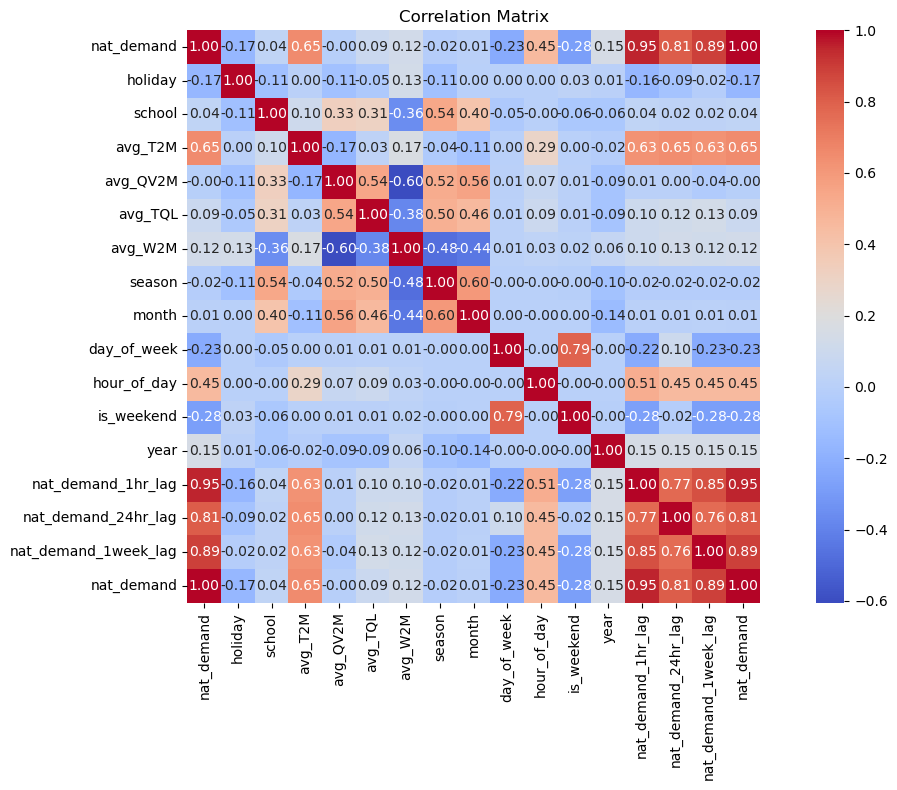

In [5]:
import seaborn as sns

# Compute correlation matrix for relevant features and target
corr_matrix = continuous_df[final_columns + ['nat_demand']].corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_matrix.png')
plt.show()

In [6]:
# Save to CSV 
final_df.to_csv('updated_dataset.csv', index=False)